In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

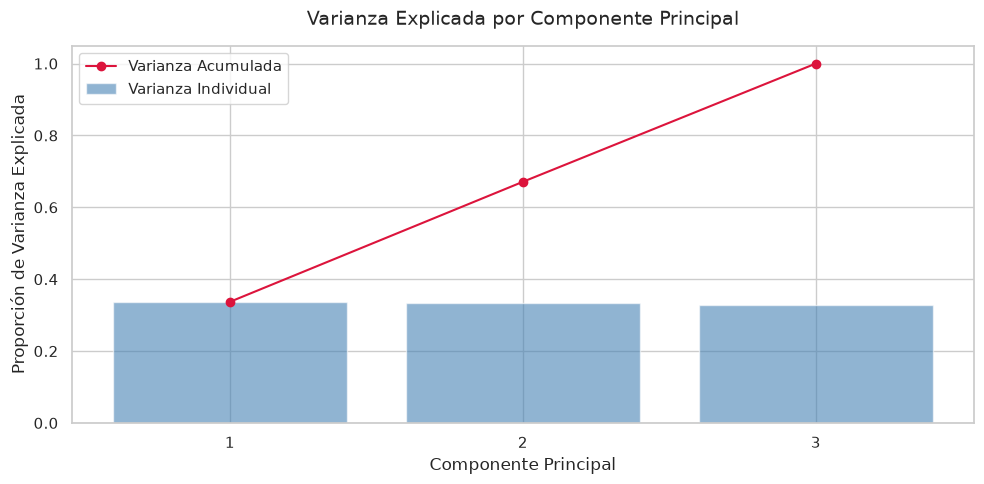

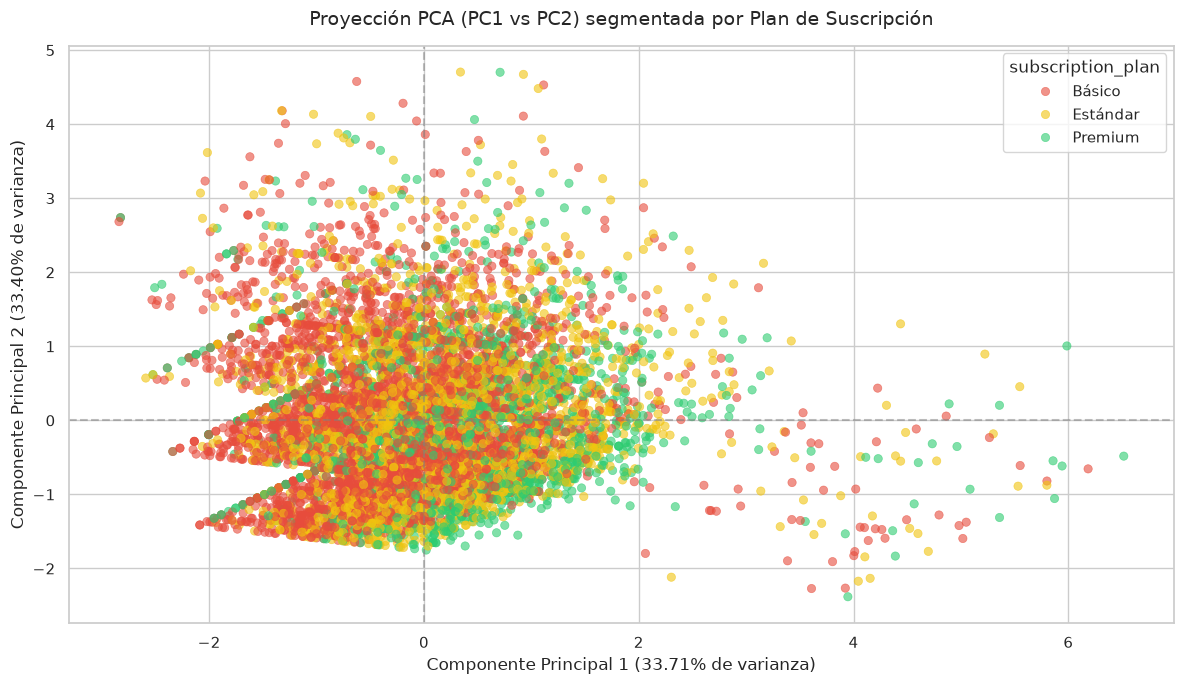

In [3]:
# Configuración estética
sns.set_theme(style="whitegrid")

# 1. Carga del dataset procesado
df = pd.read_csv('../data/processed/streaming_users_clean.csv')

# 2. Selección de las variables numéricas
columnas_num = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df[columnas_num]

# 3. Estandarización de los datos (Obligatorio para PCA)
# Esto centra la media en 0 y la desviación estándar en 1 para todas las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Entrenamiento del modelo PCA
pca = PCA()
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

# 5. Cálculo de la Varianza Explicada
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# 6. GRÁFICO 1: Gráfico de Sedimentación (Scree Plot)
# Muestra cuánta información del dataset original captura cada componente
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, color='steelblue', label='Varianza Individual')
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='crimson', label='Varianza Acumulada')
plt.title('Varianza Explicada por Componente Principal', fontsize=14, pad=15)
plt.xlabel('Componente Principal')
plt.ylabel('Proporción de Varianza Explicada')
plt.xticks([1, 2, 3])
plt.legend()
plt.tight_layout()
plt.show()

# 7. GRÁFICO 2: Proyección de Componentes 1 y 2
# Agregamos los componentes principales al dataframe temporalmente para visualizarlos
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Reutilizamos el orden y los colores de semáforo del EDA
orden_planes = ['Básico', 'Estándar', 'Premium']
colores_semaforo = ['#e74c3c', '#f1c40f', '#2ecc71']

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, x='PC1', y='PC2', 
    hue='subscription_plan', hue_order=orden_planes, palette=colores_semaforo, 
    alpha=0.6, edgecolor=None
)
plt.title('Proyección PCA (PC1 vs PC2) segmentada por Plan de Suscripción', fontsize=14, pad=15)
plt.xlabel(f'Componente Principal 1 ({varianza_explicada[0]*100:.2f}% de varianza)')
plt.ylabel(f'Componente Principal 2 ({varianza_explicada[1]*100:.2f}% de varianza)')
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()